<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml07_grandient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent(경사하강법)

*   머신러닝의 목적은 손실(비용) 함수를 최소로 만들 수 있는 모델 파라미터(w0, w1, w2, ...)들을 찾는 것.
*   회귀 문제에서 손실 함수는 MSE(w)
    *   w에 대한 2차 함수의 최솟값의 위치를 찾는 문제.
*   경사 하강법: 함수의 최솟값의 위치를 찾는 알고리즘 중의 하나.
    *   함수의 임의의 위치 w에서 시작.
    *   그 위치에서 접선의 기울기(gradient) 계산.
    *   gradient의 절댓값이 줄어드는 방향으로 w 값을 약간 수정.
    *   위의 과정을 충분히 반복하면 함수가 최소가 되는 위치를 찾을 수 있음.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

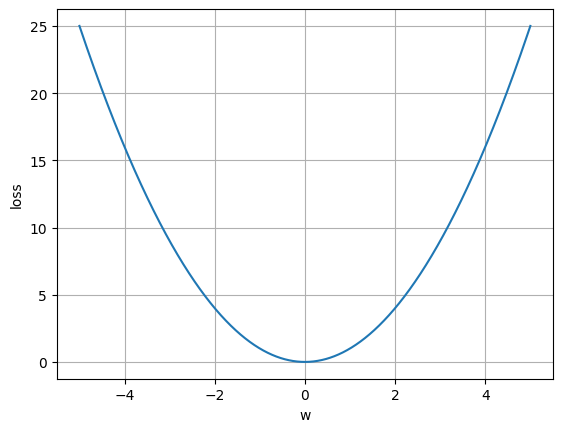

In [2]:
w = np.arange(-5, 5, 0.0001)
fn = w ** 2
plt.plot(w, fn)
plt.grid()
plt.xlabel('w')
plt.ylabel('loss')
plt.show()

In [5]:
# 임의의 w에서 시작
w_init = -4

# w_init 위치에서 gradient(접선의 기울기)를 계산
gradient = 2 * w_init

# 경사가 줄어드는 방향으로 약간 이동
w_next = w_init - gradient * 0.1

print(w_next)

-3.2


In [6]:
# 이동한 위치에서 다시 시작
w_init = w_next

# 다시 시작하는 위치에서 gradient를 계산
gradient = 2 * w_init

# 경사가 줄어드는 방향으로 약간 이동
w_next = w_init - gradient * 0.1

print(w_next)

-2.56


## 경사하강법 함수 구현

In [13]:
def gradient_descent(learning_rate=0.1, max_iter=50, tolerance=0.0001):
    # 2차 함수 f(w) = w^2 시각화
    w = np.arange(-5, 5, 0.0001)
    fn = w ** 2
    plt.plot(w, fn, color='DarkGray')

    # 임의의 w에서 시작.
    w_init = -4
    # 시작점의 위치를 점으로 표시
    plt.scatter(w_init, w_init ** 2, label='0')

    convergence = False
    for n in range(max_iter):
        # 시작점의 위치에서 경사(gradient)를 계산
        gradient = 2 * w_init  # 2차 함수 접선의 기울기 공식

        # 경사가 줄어드는 방향으로 시작점의 위치를 약간 이동
        w_next = w_init - gradient * learning_rate

        # 이동한 점의 위치를 점으로 표시
        plt.scatter(w_next, w_next ** 2, label=f'{n + 1}')

        # 반복(iteration)을 계속 할 지, 아니면 멈출 지를 결정하기 위해서
        # 이동한 위치 w_next와 이동하기 전 위치 w_init 사이의 거리가
        # tolerance보다 작은 지를 검사.
        if np.abs(w_next - w_init) < tolerance:
            convergence = True
            break  # for 반복문을 멈춤.

        # 그 다음 반복(iteration)을 시작하기 전에 시작 위치를 이동한 위치로 변경
        w_init = w_next

    print(f'최솟값의 위치 w = {w_next}')
    if convergence == False:
        print('ConvergenceWarning: 찾은 w는 정확한 최솟값이 아닐 수 있음.')

    plt.grid()
    plt.legend()
    plt.xlabel('w')
    plt.ylabel('fn')
    plt.show()

최솟값의 위치 w = -0.0003402823669209386


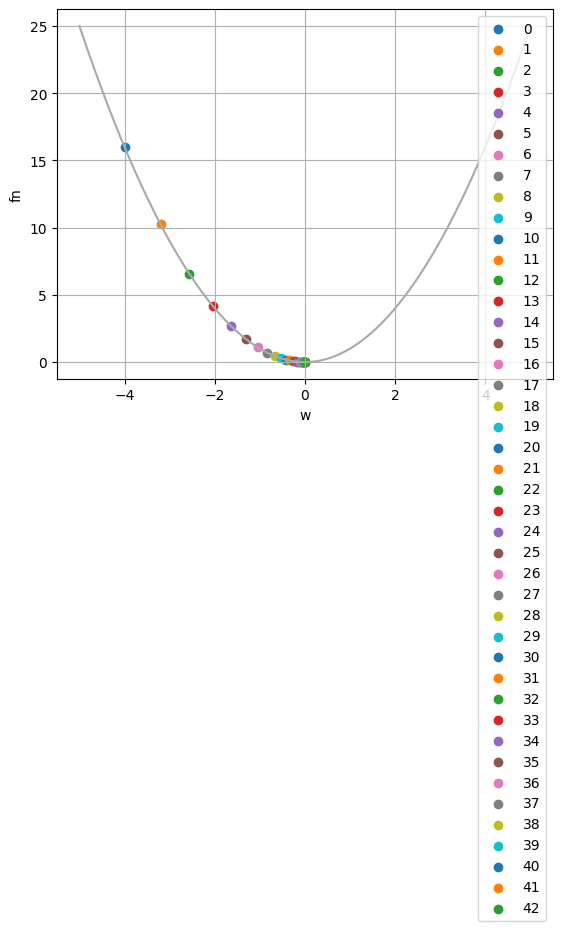

In [14]:
gradient_descent()

최솟값의 위치 w = -5.7089907708238416e-05


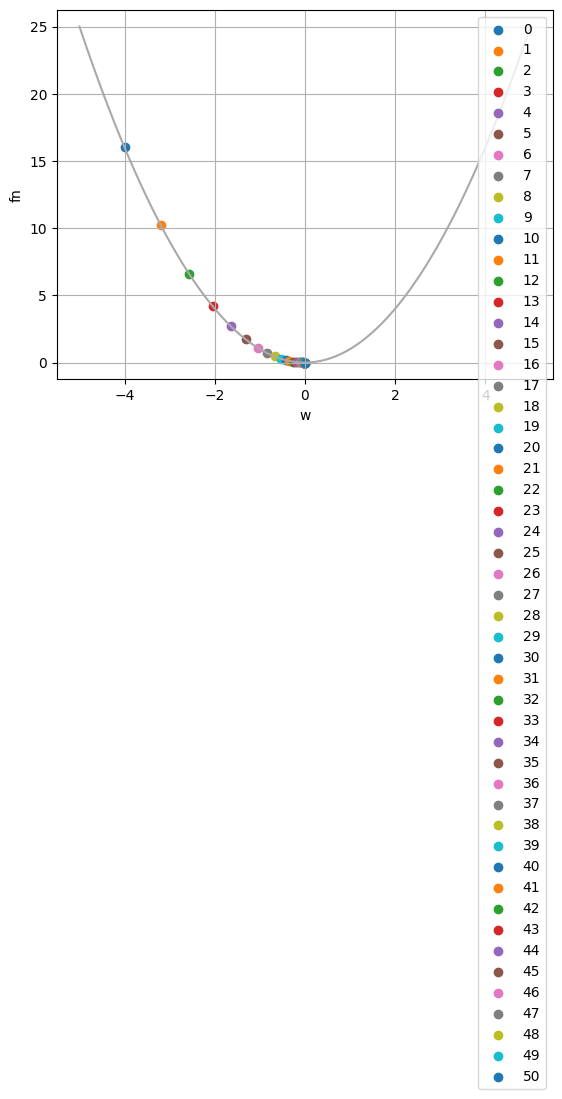

In [15]:
gradient_descent(tolerance=0.00001)

최솟값의 위치 w = -0.003961408125713218


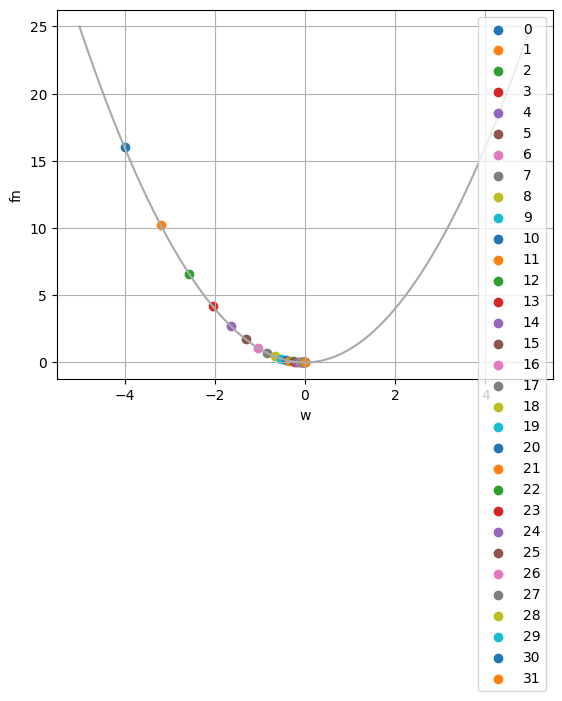

In [16]:
gradient_descent(tolerance=0.001)

최솟값의 위치 w = -3.653754093327259e-05


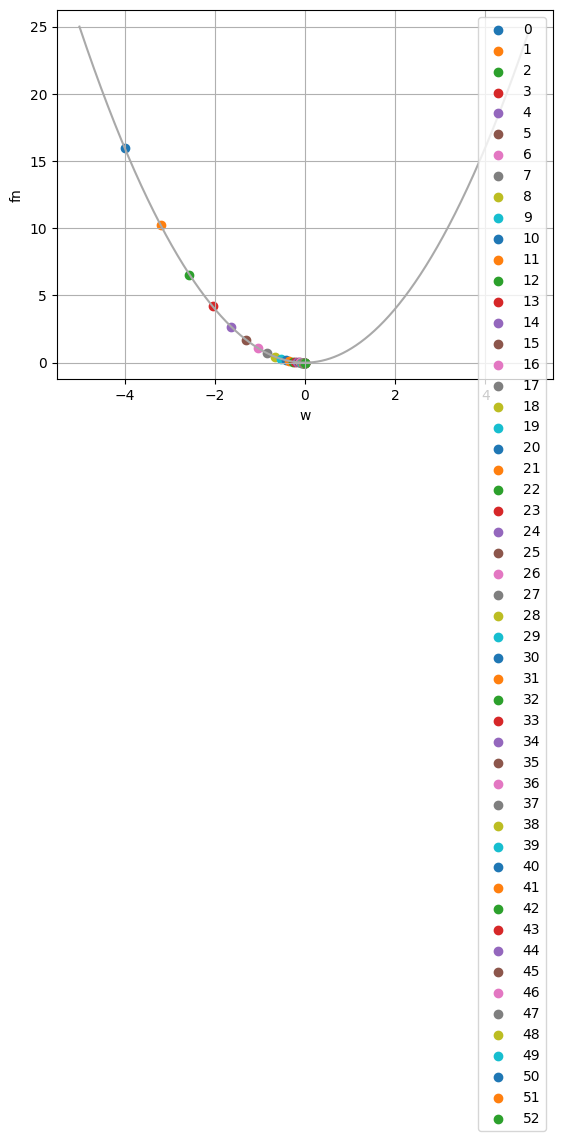

In [18]:
gradient_descent(max_iter=1_000, tolerance=0.00001)

머신러닝 모델 훈련 과정에서 ConvergenceWarning이 발생하는 경우, max_iter 파라미터 값을 더 크게 하거나 또는 더 큰 tolerance 값을 사용하면 경고를 없앨 수도 있음.

## 학습률(Learning Rate)

최솟값의 위치 w = -0.5195431740881546


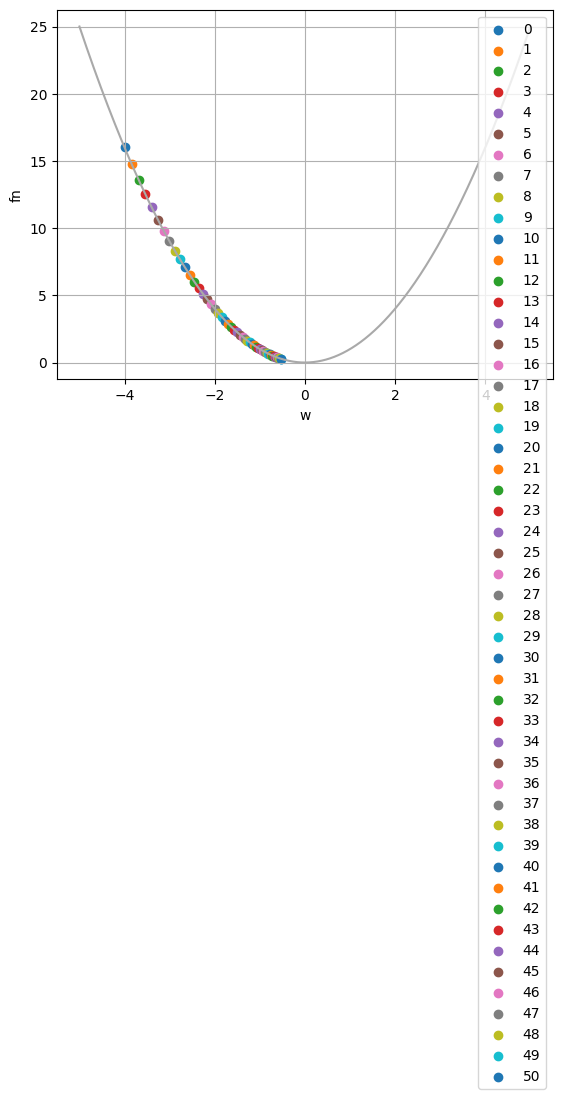

In [30]:
gradient_descent(learning_rate=0.02)

최솟값의 위치 w = -0.0001462463376025189


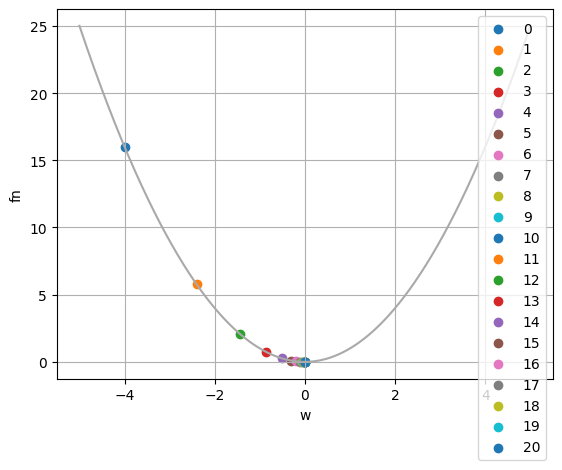

In [19]:
gradient_descent(learning_rate=0.2)

최솟값의 위치 w = 0.0


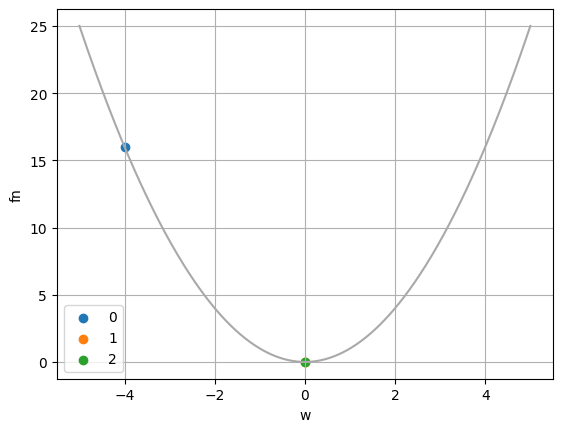

In [23]:
gradient_descent(learning_rate=0.5)

최솟값의 위치 w = 3.158920892214423e-05


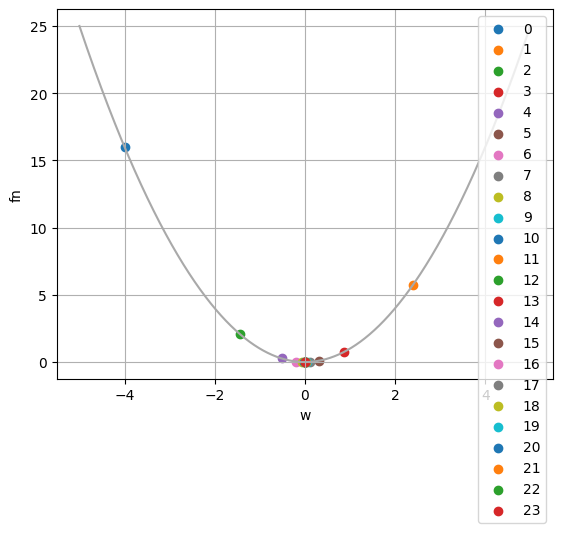

In [24]:
gradient_descent(learning_rate=0.8)

최솟값의 위치 w = -4.0


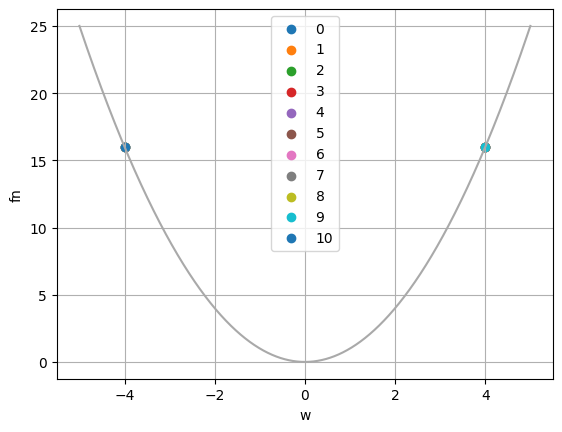

In [25]:
gradient_descent(learning_rate=1.0, max_iter=10)

최솟값의 위치 w = -24.76694568960003


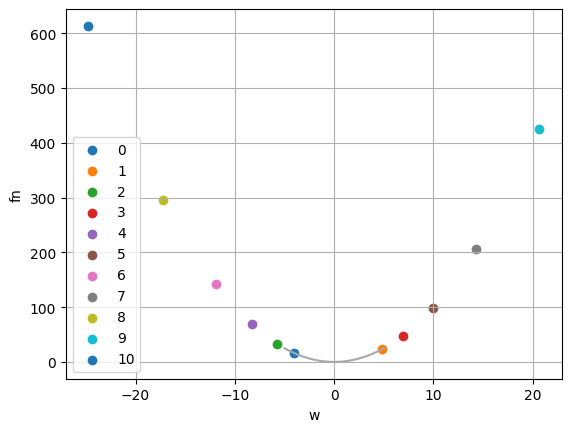

In [27]:
gradient_descent(learning_rate=1.1, max_iter=10)  # 발산(diverge)

**학습률(learning rate)** 하이퍼 파라미터:

*   학습률이 작은 경우에는 최솟값을 향해서 천천히 움직임.
*   학습률이 큰 경우에는 최솟값을 향해서 빠르게 움직이거나 불안정하게 움직임.
*   학습률이 너무 작으면 최대 반복 횟수(max_iter) 안에서 최솟값의 위치로 수렴(converge)하지 못할 수도 있음.
    *   학습률을 더 크게 변경.
    *   최대 반복 횟수를 늘림.
    *   수렴 기준(tolerance)을 완화(tolerance를 크게).
*   학습률이 너무 크면 수렴하지 못하고 발산(diverge)하는 경우가 생기기도 함.
    *   반드시 학습률을 줄여야 함.
*   머신러닝 알고리즘들 중에서는 처음에는 학습률을 크게 하고, 반복(iteration)이 진행될 때마다 학습률을 점진적으로 줄여 나가는 방식으로 데이터를 학습하는 알고리즘도 있음.

# SGDRegressor

확률적 경사 하강법(Stochastic Gradient Descent) 알고리즘을 사용해서 손실함수(MSE)가 최소가 되는 모델 파라미터들을 찾아서 수치를 예측하는 머신러닝 모델.

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

In [32]:
file_path = 'https://bit.ly/fish_csv_data'

In [33]:
fish = pd.read_csv(file_path)

In [34]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [35]:
perch = fish[fish.Species == 'Perch']

In [36]:
x = perch[perch.columns[2:]].values  # 특성(features)
y = perch.Weight.values  # 타겟(target)

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.25,
                                                    random_state=42)

In [39]:
sgd = SGDRegressor()  # 확률적 경사하강법을 사용한 회귀 모델을 생성

In [40]:
sgd.fit(X=x_train, y=y_train)  # 모델 훈련

SGDRegressor()

In [41]:
sgd.coef_  # SGD 모델이 찾은 계수들

array([-1.18334577e+10,  1.51681041e+10,  2.09973863e+10,  3.41670844e+10])

In [42]:
sgd.intercept_  # SGD 모델이 찾은 절편

array([4.03077613e+10])

In [43]:
sgd.score(X=x_train, y=y_train)  # train r2 score

-2.1799120432092529e+18

In [44]:
sgd.score(X=x_test, y=y_test)  # test r2 score

-2.349505627977088e+18

훈련 셋의 샘플 개수(42개)가 너무 작아서 1,000번 에포크(epoch = max_iter)만으로는 최적의 값으로 수렴하지 못하기 때문에 결정계수가 너무 작음(예측 성능이 너무 안좋음).

해결 방법:

*   최대 반복 횟수(max_iter) 늘려줌.
*   규제(penalty)의 크기(alpha)를 줄임.
*   학습률(learning_rate, eta0, power_t)을 크게 함.


## 학습률 하이퍼 파라미터 튜닝

SGDRegressor를 사용:

*  max_iter = 1_000_000_000
*   learning_rate = ['constant', 'optimal', 'invscaling', 'adaptive']: 학습률 종류
*   eta0 = [0.01, 0.1, 0.5, 1.0, 2.0]: 초기 학습률
*   훈련 셋과 테스트 셋에서 결정계수를 계산, 출력
